<a href="https://colab.research.google.com/github/jaydenhurt1215-dotcom/CS4410-HW/blob/main/JHurt_Hw_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

S1: Load breast cancer dataset

In [27]:
from sklearn.datasets import load_breast_cancer
breast_cancer = load_breast_cancer()

print(breast_cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

S2: Check sample and target sizes

In [28]:
breast_cancer.data.shape

(569, 30)

In [29]:
breast_cancer.target.shape

(569,)

S3: Split data for training and testing

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(breast_cancer.data, breast_cancer.target, random_state=11)

S4:Training and testing set sizes

In [31]:
X_train.shape

(426, 30)

In [32]:
X_test.shape

(143, 30)

S5: Create Model (GaussianNB)

In [33]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

S6: Train the Model

In [34]:
nb.fit(X_train, y_train)

GaussianNB()

S7: Predicting

In [35]:
predicted=nb.predict(X_test)

In [36]:
expected=y_test

print('Expected:', expected[:20])
print('Predicted:', predicted[:20])

Expected: [0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0]
Predicted: [0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0]


Step 8: Estimator Method Score()

In [37]:
nb.score(X_test, y_test)

0.951048951048951

S9: Confusion Matrix

In [38]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test, predicted)
confusion

array([[44,  6],
       [ 1, 92]])

S10: Classification Report

In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.98      0.88      0.93        50
           1       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



S11: Visualizing the confusion matrix

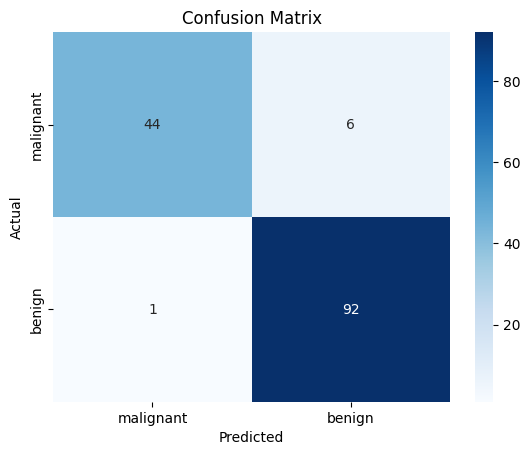

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

axes = sns.heatmap(confusion, annot=True, fmt='d', cmap="Blues", xticklabels=breast_cancer.target_names, yticklabels=breast_cancer.target_names)
axes.set_xlabel("Predicted")
axes.set_ylabel("Actual")
axes.set_title("Confusion Matrix")

plt.show()

S12: K-fold cross-validation

In [41]:
from sklearn.model_selection import KFold
KFold = KFold(n_splits=10, random_state=11, shuffle=True)

In [42]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(estimator=nb, X=breast_cancer.data, y=breast_cancer.target, cv=KFold)
scores

array([0.96491228, 0.9122807 , 0.94736842, 0.89473684, 0.96491228,
       0.94736842, 0.96491228, 0.89473684, 0.96491228, 0.92857143])

In [43]:
print('Mean Accuracy:', scores.mean())
print('Standard Deviation:', scores.std())

Mean Accuracy: 0.9384711779448622
Standard Deviation: 0.02750305414538902


S13: Run multiple models to find best one

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

estimators = { 'GaussianNB': nb, 'KNeighborsClassifier': KNeighborsClassifier(), 'LogisticRegression': LogisticRegression(solver='lbfgs', multi_class='ovr', max_iter=10000), 'SVC': SVC(gamma='scale') }

for name, estimator in estimators.items():
  scores = cross_val_score(estimator=estimator, X=breast_cancer.data, y=breast_cancer.target, cv=KFold)

  print(name)
  print('Mean Accuracy:', scores.mean())
  print('Standard Deviation:', scores.std())
  print()

GaussianNB
Mean Accuracy: 0.9384711779448622
Standard Deviation: 0.02750305414538902

KNeighborsClassifier
Mean Accuracy: 0.9279135338345865
Standard Deviation: 0.02005523998830162



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

LogisticRegression
Mean Accuracy: 0.950814536340852
Standard Deviation: 0.030155034463240953

SVC
Mean Accuracy: 0.9191729323308271
Standard Deviation: 0.035227300242783435

